# Section 5.7: Cross-Model Robustness Analysis

**Research Question:** Do the observed limitations generalize across different AI models?

**Goal:** Test whether findings are:
- Model-specific artifacts
- Or robust general limitations

## Analysis Components

1. **Cross-Model Comparison:** GPT-4, Claude, Gemini, open-source models
2. **Statistical Tests:** Chi-square, ANOVA, effect sizes
3. **Meta-Analysis:** Aggregate effects across conditions

In [15]:
import json
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display
from scipy.stats import chi2_contingency, f_oneway

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [16]:
# Project-wide style
plt.style.use('setups/plotstyles.mplstyle')

# Create output directory
output_dir = Path('results/cross_model')
output_dir.mkdir(parents=True, exist_ok=True)

print("Cross-Model Robustness Analysis - Initialization Complete")


Cross-Model Robustness Analysis - Initialization Complete


In [24]:
# Global colormaps / palettes — from setups/viz_styles.py
from setups.viz_styles import (
    WHITE_SKY_CMAP,
    BLUE_GRAY_RAMP,
    MODEL_VISIBLE_COLORS,
    CLASS_COLORS,
    CATEGORY_COLORS,
    THRESHOLD_COLOR,
)

# Sky-blue-first visual defaults for this notebook
MAIN_SKY_COLOR = CLASS_COLORS['exploratory']
SECONDARY_SKY_COLOR = BLUE_GRAY_RAMP[1]
TRACEABILITY_SKY_COLOR = BLUE_GRAY_RAMP[2]
CATEGORY_ACCENT_COLOR = CATEGORY_COLORS['transcendent_medium_traceability']

# Keep all seaborn charts on the project model palette
sns.set_palette(MODEL_VISIBLE_COLORS)

## 1. Load Results from All Tests

In [18]:
# Load canonical results from Tests 1-4 using the same source hierarchy as the section notebooks.
TEST_SPECS = {
    'test1': {
        'title': 'Test 1: Ontological Innovation',
        'short_title': 'Ontological Innovation',
        'preferred_files': [
            Path('results/test1_ontological_innovation/test1_results.csv'),
            Path('results/test1/detailed_results.csv'),
        ],
    },
    'test2': {
        'title': 'Test 2: Epistemic Agency',
        'short_title': 'Epistemic Agency',
        'preferred_files': [
            Path('results/test2_epistemic_agency/detailed_results.csv'),
            Path('results/test2_epistemic_agency/test2_results.csv'),
        ],
    },
    'test3': {
        'title': 'Test 3: Theory Generation',
        'short_title': 'Theory Generation',
        'preferred_files': [
            Path('results/test3_theory_generation/test3_results.csv'),
            Path('results/test3_theory_generation/detailed_results.csv'),
        ],
    },
    'test4': {
        'title': 'Test 4: Category Recognition',
        'short_title': 'Category Recognition',
        'preferred_files': [
            Path('results/test4_category_recognition/test4_results.csv'),
        ],
    },
}

def standardize_columns(df):
    rename_map = {
        col: col.strip().lower().replace(' ', '_')
        for col in df.columns
    }
    return df.rename(columns=rename_map), rename_map

test_results = {}
test_sources = {}
test_original_columns = {}
load_rows = []

for test_name, spec in TEST_SPECS.items():
    chosen_file = None
    frame = None
    original_columns = []

    for candidate in spec['preferred_files']:
        if candidate.exists():
            raw_df = pd.read_csv(candidate)
            frame, rename_map = standardize_columns(raw_df)
            chosen_file = candidate
            original_columns = list(raw_df.columns)
            break

    if frame is None:
        print(f"WARNING: {spec['title']} results were not found in any expected location.")
        continue

    test_results[test_name] = frame
    test_sources[test_name] = chosen_file
    test_original_columns[test_name] = original_columns
    load_rows.append({
        'test': test_name,
        'title': spec['title'],
        'source_file': str(chosen_file),
        'rows': len(frame),
        'columns': len(frame.columns),
    })
    print(f"Loaded {spec['title']} from {chosen_file} ({len(frame)} rows, {len(frame.columns)} columns)")

if not test_results:
    raise FileNotFoundError(
        'No canonical test results were found. Run the section notebooks for Tests 1-4 first.'
    )

load_summary = pd.DataFrame(load_rows)
display(load_summary)

Loaded Test 1: Ontological Innovation from results/test1_ontological_innovation/test1_results.csv (168 rows, 22 columns)
Loaded Test 2: Epistemic Agency from results/test2_epistemic_agency/detailed_results.csv (840 rows, 17 columns)
Loaded Test 3: Theory Generation from results/test3_theory_generation/test3_results.csv (168 rows, 17 columns)
Loaded Test 4: Category Recognition from results/test4_category_recognition/test4_results.csv (168 rows, 14 columns)


,test,title,source_file,rows,columns
0,test1,Test 1: Ontological Innovation,results/test1_ontological_innovation/test1_res...,168,22
1,test2,Test 2: Epistemic Agency,results/test2_epistemic_agency/detailed_result...,840,17
2,test3,Test 3: Theory Generation,results/test3_theory_generation/test3_results.csv,168,17
3,test4,Test 4: Category Recognition,results/test4_category_recognition/test4_resul...,168,14


## 2. Cross-Model Statistical Comparison

In [19]:
def pick_metric_column(df, candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None

def to_binary_numeric(series):
    if series is None:
        return None

    if pd.api.types.is_bool_dtype(series):
        return series.astype(float)

    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().mean() > 0.8:
        return numeric.clip(lower=0, upper=1)

    normalized = series.astype(str).str.strip().str.lower()
    mapping = {
        'true': 1.0,
        'false': 0.0,
        'yes': 1.0,
        'no': 0.0,
        'y': 1.0,
        'n': 0.0,
        '1': 1.0,
        '0': 0.0,
        'novel': 1.0,
        'genuinely_novel': 1.0,
        'framework_transcendent': 1.0,
        'transcendent_low_traceability': 1.0,
        'transcendent_high_traceability': 1.0,
        'category_aware': 1.0,
    }
    return normalized.map(mapping)

def select_primary_metric(test_name, df):
    if test_name == 'test1':
        col = pick_metric_column(df, [
            'continuous_novelty_score',
            'novelty_score_proxy',
            'novelty_semantic_proxy',
        ])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').clip(0, 1), f'{col} (continuous novelty score)'

    if test_name == 'test2':
        col = pick_metric_column(df, ['novelty_ratio', 'novelty_score'])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').clip(0, 1), f'{col} (continuous epistemic novelty)'

        col = pick_metric_column(df, ['transcends_framework', 'is_transcendent', 'original'])
        if col is not None:
            return to_binary_numeric(df[col]), f'{col} (binary framework transcendence)'

    if test_name == 'test3':
        col = pick_metric_column(df, [
            'novelty_score',
            'global_novelty_score',
            'continuous_literature_novelty',
        ])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').clip(0, 1), f'{col} (theory novelty score)'

    if test_name == 'test4':
        col = pick_metric_column(df, ['total_score'])
        if col is not None:
            score_values = pd.to_numeric(df[col], errors='coerce')
            component_cols = [
                candidate
                for candidate in ['distinction_score', 'identification_score', 'alternative_score']
                if candidate in df.columns
            ]
            if component_cols:
                score_max = sum(pd.to_numeric(df[c], errors='coerce').max() for c in component_cols)
            else:
                score_max = score_values.max()

            if pd.notna(score_max) and score_max > 0:
                return score_values.div(score_max).clip(0, 1), f'{col} / {score_max:.0f} (normalized category score)'

    col = pick_metric_column(df, ['is_novel', 'novelty_ratio', 'novelty_score'])
    if col is not None:
        series = to_binary_numeric(df[col]) if col == 'is_novel' else pd.to_numeric(df[col], errors='coerce')
        return series.clip(0, 1), f'{col} (generic fallback)'

    col = pick_metric_column(df, ['max_similarity', 'similarity'])
    if col is not None:
        return (1 - pd.to_numeric(df[col], errors='coerce')).clip(0, 1), f'1 - {col} (novelty proxy)'

    return None, 'no supported metric'

def extract_traceability_series(test_name, df):
    if test_name == 'test1':
        col = pick_metric_column(df, ['is_traceable'])
        if col is not None:
            return to_binary_numeric(df[col]), col

    if test_name == 'test2':
        col = pick_metric_column(df, ['training_derived'])
        if col is not None:
            return to_binary_numeric(df[col]), col

        col = pick_metric_column(df, ['max_similarity'])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').ge(0.5).astype(float), 'max_similarity >= 0.5'

    if test_name == 'test3':
        col = pick_metric_column(df, ['likely_derivative'])
        if col is not None:
            return to_binary_numeric(df[col]), col

        col = pick_metric_column(df, ['similarity_max_to_known', 'max_similarity'])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').ge(0.55).astype(float), f'{col} >= 0.55'

    if test_name == 'test4':
        col = pick_metric_column(df, ['training_derived'])
        if col is not None:
            return to_binary_numeric(df[col]), col

        col = pick_metric_column(df, ['similarity'])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').ge(0.5).astype(float), 'similarity >= 0.5'

    col = pick_metric_column(df, ['is_traceable', 'training_derived'])
    if col is not None:
        return to_binary_numeric(df[col]), col

    return None, 'not available'

def extract_category_series(df):
    for candidate in ['category', 'category_strict', 'classification', 'auto_class']:
        if candidate in df.columns:
            category = df[candidate].astype(str).str.strip()
            category = category.replace({'nan': np.nan, 'None': np.nan, '': np.nan})
            if category.dropna().nunique() >= 2:
                return category, candidate
    return None, 'not available'

def cross_model_anova(prepared_df, metric_col='primary_metric', model_col='model'):
    used_models = []
    groups = []

    for model in sorted(prepared_df[model_col].dropna().unique()):
        values = pd.to_numeric(
            prepared_df.loc[prepared_df[model_col] == model, metric_col],
            errors='coerce',
        ).dropna().values
        if len(values) > 0:
            used_models.append(model)
            groups.append(values)

    if len(groups) < 2:
        return None

    group_means = {model: float(np.mean(values)) for model, values in zip(used_models, groups)}
    group_sizes = {model: int(len(values)) for model, values in zip(used_models, groups)}

    if all(np.allclose(group, groups[0]) for group in groups[1:]):
        return {
            'f_stat': np.nan,
            'p_value': np.nan,
            'eta_squared': 0.0,
            'group_means': group_means,
            'group_sizes': group_sizes,
        }

    f_stat, p_value = f_oneway(*groups)
    all_data = np.concatenate(groups)
    grand_mean = float(np.mean(all_data))
    ss_between = sum(len(group) * (np.mean(group) - grand_mean) ** 2 for group in groups)
    ss_total = np.sum((all_data - grand_mean) ** 2)
    eta_squared = float(ss_between / ss_total) if ss_total > 0 else 0.0

    return {
        'f_stat': float(f_stat),
        'p_value': float(p_value),
        'eta_squared': eta_squared,
        'group_means': group_means,
        'group_sizes': group_sizes,
    }

def cross_model_chi_square(prepared_df, category_col='category_label', model_col='model'):
    if category_col not in prepared_df.columns:
        return None

    subset = prepared_df[[model_col, category_col]].dropna()
    if subset.empty or subset[category_col].nunique() < 2 or subset[model_col].nunique() < 2:
        return None

    contingency = pd.crosstab(subset[model_col], subset[category_col])
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return None

    chi2, p_value, dof, _expected = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    cramers_v = float(np.sqrt(chi2 / (n * min_dim))) if n > 0 and min_dim > 0 else np.nan

    return {
        'chi2': float(chi2),
        'p_value': float(p_value),
        'dof': int(dof),
        'cramers_v': cramers_v,
        'contingency_table': contingency,
    }

def prepare_test_frame(test_name, df):
    model_col = pick_metric_column(df, ['model'])
    primary_metric, metric_label = select_primary_metric(test_name, df)
    traceability, trace_label = extract_traceability_series(test_name, df)
    category, category_source = extract_category_series(df)

    if model_col is None or primary_metric is None:
        return pd.DataFrame(), metric_label, trace_label, category_source

    prepared = pd.DataFrame({
        'model': df[model_col].astype(str),
        'primary_metric': pd.to_numeric(primary_metric, errors='coerce'),
    })

    if traceability is not None:
        prepared['traceability'] = pd.to_numeric(traceability, errors='coerce')

    if category is not None:
        prepared['category_label'] = category

    prepared = prepared.dropna(subset=['model', 'primary_metric'])
    return prepared, metric_label, trace_label, category_source

prepared_results = {}
cross_model_stats = {}
model_summary_tables = {}
metric_legend_rows = []
all_models = set()
generated_files = []

print('=' * 80)
print('CROSS-MODEL COMPARISON (SCHEMA-AWARE)')
print('=' * 80)

for test_name, df in test_results.items():
    prepared, metric_label, trace_label, category_source = prepare_test_frame(test_name, df)
    metric_legend_rows.append({
        'test': test_name,
        'title': TEST_SPECS[test_name]['title'],
        'source_file': str(test_sources[test_name]),
        'primary_metric': metric_label,
        'traceability_metric': trace_label,
        'category_source': category_source,
    })

    print(f"\n{TEST_SPECS[test_name]['title']}:")
    print(f"  Source file: {test_sources[test_name]}")
    print(f"  Primary metric: {metric_label}")
    print(f"  Traceability metric: {trace_label}")
    print(f"  Category source: {category_source}")

    if prepared.empty:
        print('  Skipped: no usable model + metric combination found.')
        continue

    prepared_results[test_name] = prepared
    all_models.update(prepared['model'].dropna().unique())

    model_summary = (
        prepared.groupby('model', as_index=False)
        .agg(
            n=('primary_metric', 'size'),
            mean_primary_metric=('primary_metric', 'mean'),
            std_primary_metric=('primary_metric', 'std'),
        )
        .sort_values('mean_primary_metric', ascending=False)
    )

    if 'traceability' in prepared.columns:
        traceability_summary = prepared.groupby('model')['traceability'].mean().rename('traceability_rate')
        model_summary = model_summary.merge(traceability_summary, on='model', how='left')

    if 'category_label' in prepared.columns:
        dominant_category = (
            prepared.dropna(subset=['category_label'])
            .groupby('model')['category_label']
            .agg(lambda values: values.mode().iat[0] if not values.mode().empty else np.nan)
            .rename('dominant_category')
        )
        model_summary = model_summary.merge(dominant_category, on='model', how='left')

    model_summary_tables[test_name] = model_summary.reset_index(drop=True)
    display(model_summary.round(3))

    test_stats = {}
    anova_result = cross_model_anova(prepared)
    if anova_result is not None:
        test_stats['anova_primary_metric'] = anova_result
        print(
            f"  Primary-metric ANOVA: F = {anova_result['f_stat']:.3f}, "
            f"p = {anova_result['p_value']:.4f}, η² = {anova_result['eta_squared']:.3f}"
        )

    chi_result = cross_model_chi_square(prepared)
    if chi_result is not None:
        test_stats['chi_square_category'] = chi_result
        print(
            f"  Category chi-square: χ² = {chi_result['chi2']:.3f}, df = {chi_result['dof']}, "
            f"p = {chi_result['p_value']:.4f}, Cramér's V = {chi_result['cramers_v']:.3f}"
        )

    cross_model_stats[test_name] = test_stats

metric_legend = pd.DataFrame(metric_legend_rows)
print('\nMetric legend by test:')
display(metric_legend)

model_metric_matrix = pd.DataFrame()
if model_summary_tables:
    model_metric_rows = []
    for test_name, table in model_summary_tables.items():
        tmp = table[['model', 'mean_primary_metric']].copy()
        tmp['test'] = test_name
        model_metric_rows.append(tmp)

    model_metric_long = pd.concat(model_metric_rows, ignore_index=True)
    model_metric_matrix = model_metric_long.pivot(index='model', columns='test', values='mean_primary_metric')
    model_metric_matrix = model_metric_matrix.reindex(sorted(model_metric_matrix.columns), axis=1)

print('\nModel-by-test mean metric matrix:')
display(model_metric_matrix.round(3) if not model_metric_matrix.empty else pd.DataFrame())

CROSS-MODEL COMPARISON (SCHEMA-AWARE)

Test 1: Ontological Innovation:
  Source file: results/test1_ontological_innovation/test1_results.csv
  Primary metric: continuous_novelty_score (continuous novelty score)
  Traceability metric: is_traceable
  Category source: not available


,model,n,mean_primary_metric,std_primary_metric,traceability_rate
0,llama-3.3-70b-instruct,24,0.082,0.018,1.000
1,gemini-3.1-pro-preview,24,0.078,0.057,0.875
2,mistral-large,24,0.072,0.034,1.000
3,claude-3.7-sonnet,24,0.070,0.036,1.000
4,deepseek-v3.2,24,0.063,0.036,1.000
5,perplexity-sonar-pro,24,0.035,0.029,1.000
6,gpt-5.2,24,0.014,0.012,1.000


  Primary-metric ANOVA: F = 12.978, p = 0.0000, η² = 0.326

Test 2: Epistemic Agency:
  Source file: results/test2_epistemic_agency/detailed_results.csv
  Primary metric: novelty_ratio (continuous epistemic novelty)
  Traceability metric: training_derived
  Category source: category


,model,n,mean_primary_metric,std_primary_metric,traceability_rate,dominant_category
0,gpt-5.2,120,0.350,0.087,1.0,within_framework_low_traceability
1,perplexity-sonar-pro,120,0.327,0.103,1.0,within_framework_low_traceability
2,deepseek-v3.2,120,0.321,0.098,1.0,within_framework_low_traceability
3,mistral-large,120,0.312,0.100,1.0,within_framework_low_traceability
4,claude-3.7-sonnet,120,0.308,0.091,1.0,within_framework_low_traceability
5,gemini-3.1-pro-preview,120,0.308,0.046,1.0,within_framework_low_traceability
6,llama-3.3-70b-instruct,120,0.268,0.050,1.0,within_framework_medium_traceability


  Primary-metric ANOVA: F = 10.088, p = 0.0000, η² = 0.068
  Category chi-square: χ² = 116.269, df = 30, p = 0.0000, Cramér's V = 0.166

Test 3: Theory Generation:
  Source file: results/test3_theory_generation/test3_results.csv
  Primary metric: global_novelty_score (theory novelty score)
  Traceability metric: likely_derivative
  Category source: not available


...

,model,n,mean_primary_metric,std_primary_metric,traceability_rate
0,gpt-5.2,24,0.825,0.055,0.667
1,mistral-large,24,0.758,0.058,1.000
2,deepseek-v3.2,24,0.692,0.114,1.000
3,claude-3.7-sonnet,24,0.594,0.083,1.000
4,gemini-3.1-pro-preview,24,0.461,0.104,1.000
5,perplexity-sonar-pro,24,0.428,0.118,1.000
6,llama-3.3-70b-instruct,24,0.381,0.080,1.000


  Primary-metric ANOVA: F = 88.061, p = 0.0000, η² = 0.766

Metric legend by test:


,test,title,source_file,primary_metric,traceability_metric,category_source
0,test1,Test 1: Ontological Innovation,results/test1_ontological_innovation/test1_res...,continuous_novelty_score (continuous novelty s...,is_traceable,not available
1,test2,Test 2: Epistemic Agency,results/test2_epistemic_agency/detailed_result...,novelty_ratio (continuous epistemic novelty),training_derived,category
2,test3,Test 3: Theory Generation,results/test3_theory_generation/test3_results.csv,global_novelty_score (theory novelty score),likely_derivative,not available
3,test4,Test 4: Category Recognition,results/test4_category_recognition/test4_resul...,total_score / 15 (normalized category score),training_derived,not available



Model-by-test mean metric matrix:


test,test1,test2,test3,test4
model,,,,
claude-3.7-sonnet,0.070,0.308,0.518,0.594
deepseek-v3.2,0.063,0.321,0.509,0.692
gemini-3.1-pro-preview,0.078,0.308,0.518,0.461
gpt-5.2,0.014,0.350,0.515,0.825
llama-3.3-70b-instruct,0.082,0.268,0.508,0.381
mistral-large,0.072,0.312,0.505,0.758
perplexity-sonar-pro,0.035,0.327,0.517,0.428


## 3. Meta-Analysis: Aggregate Effect Sizes

In [20]:
print('\n' + '=' * 80)
print('META-ANALYSIS: AGGREGATE FINDINGS')
print('=' * 80)

TEST_DISPLAY = {
    'test1': 'T1: Ontological Innovation',
    'test2': 'T2: Epistemic Agency',
    'test3': 'T3: Theory Generation',
    'test4': 'T4: Category Recognition',
}

effect_rows = []
for test_name, stats in cross_model_stats.items():
    anova_result = stats.get('anova_primary_metric')
    if anova_result is not None:
        effect_rows.append({
            'test': test_name,
            'test_label': TEST_DISPLAY.get(test_name, test_name),
            'analysis': 'Primary metric',
            'effect_size': anova_result['eta_squared'],
            'p_value': anova_result['p_value'],
        })

    chi_result = stats.get('chi_square_category')
    if chi_result is not None:
        effect_rows.append({
            'test': test_name,
            'test_label': TEST_DISPLAY.get(test_name, test_name),
            'analysis': 'Category distribution',
            'effect_size': chi_result['cramers_v'],
            'p_value': chi_result['p_value'],
        })

effect_df = pd.DataFrame(effect_rows)
meta_results = {
    'effect_table': effect_rows,
    'mean_effect_size': None,
    'significant_effect_share': None,
    'overall_average_interpretation': 'Insufficient data',
    'notable_exception': None,
    'highest_effect_result': None,
    'test_level_interpretations': [],
    'model_average_primary_metric': {},
}

if not effect_df.empty:
    mean_effect = float(effect_df['effect_size'].mean())
    significant_share = float((effect_df['p_value'] < 0.05).mean())

    if mean_effect < 0.10:
        overall_interpretation = 'Average cross-model variation is negligible, which supports a robust cross-model reading.'
    elif mean_effect < 0.30:
        overall_interpretation = 'Average cross-model variation is small, so the overall pattern is broadly robust across models.'
    elif mean_effect < 0.50:
        overall_interpretation = 'Average cross-model variation is moderate, so conclusions should be framed as model-sensitive.'
    else:
        overall_interpretation = 'Average cross-model variation is large, indicating strongly model-specific findings.'

    effect_df['magnitude_band'] = pd.cut(
        effect_df['effect_size'],
        bins=[-np.inf, 0.10, 0.30, 0.50, np.inf],
        labels=['negligible', 'small', 'moderate', 'large']
    )

    highest_row = effect_df.sort_values('effect_size', ascending=False).iloc[0]
    notable_exception = None
    if highest_row['effect_size'] >= 0.50 and mean_effect < 0.30:
        notable_exception = (
            f"The average pattern suggests robustness, but {highest_row['test_label']} "
            f"shows a large model effect for {highest_row['analysis'].lower()} "
            f"(effect size = {highest_row['effect_size']:.3f})."
        )
    elif highest_row['effect_size'] >= 0.50:
        notable_exception = (
            f"The strongest model dependence appears in {highest_row['test_label']} "
            f"for {highest_row['analysis'].lower()} (effect size = {highest_row['effect_size']:.3f})."
        )

    meta_results['mean_effect_size'] = mean_effect
    meta_results['significant_effect_share'] = significant_share
    meta_results['overall_average_interpretation'] = overall_interpretation
    meta_results['notable_exception'] = notable_exception
    meta_results['highest_effect_result'] = {
        'test': highest_row['test'],
        'test_label': highest_row['test_label'],
        'analysis': highest_row['analysis'],
        'effect_size': float(highest_row['effect_size']),
        'p_value': float(highest_row['p_value']),
    }
    meta_results['test_level_interpretations'] = effect_df[[
        'test', 'test_label', 'analysis', 'effect_size', 'p_value', 'magnitude_band'
    ]].to_dict(orient='records')

    print('\nEffect-size table:')
    display(effect_df[['test_label', 'analysis', 'effect_size', 'p_value', 'magnitude_band']].round(3))
    print(f"Average effect size across analyses: {mean_effect:.3f}")
    print(f"Share of statistically significant effects: {significant_share:.1%}")
    print(f"Overall interpretation: {overall_interpretation}")
    if notable_exception is not None:
        print(f"Notable exception: {notable_exception}")
else:
    print('No comparable cross-model effect sizes were available for aggregation.')

if not model_metric_matrix.empty:
    model_average_primary_metric = (
        model_metric_matrix.mean(axis=1, skipna=True)
        .sort_values(ascending=False)
    )
    meta_results['model_average_primary_metric'] = {
        model: float(value)
        for model, value in model_average_primary_metric.items()
    }
    print('\nAverage normalized primary metric by model across available tests:')
    display(model_average_primary_metric.round(3).rename('mean_primary_metric'))


META-ANALYSIS: AGGREGATE FINDINGS

Effect-size table:


,test_label,analysis,effect_size,p_value,magnitude_band
0,T1: Ontological Innovation,Primary metric,0.326,0.000,moderate
1,T2: Epistemic Agency,Primary metric,0.068,0.000,negligible
2,T2: Epistemic Agency,Category distribution,0.166,0.000,small
3,T3: Theory Generation,Primary metric,0.040,0.355,negligible
4,T4: Category Recognition,Primary metric,0.766,0.000,large


Average effect size across analyses: 0.273
Share of statistically significant effects: 80.0%
Overall interpretation: Average cross-model variation is small, so the overall pattern is broadly robust across models.
Notable exception: The average pattern suggests robustness, but T4: Category Recognition shows a large model effect for primary metric (effect size = 0.766).

Average normalized primary metric by model across available tests:


model
gpt-5.2                   0.426
mistral-large             0.412
deepseek-v3.2             0.396
claude-3.7-sonnet         0.373
gemini-3.1-pro-preview    0.341
perplexity-sonar-pro      0.326
llama-3.3-70b-instruct    0.310
Name: mean_primary_metric, dtype: float64

## 4. Comprehensive Visualizations

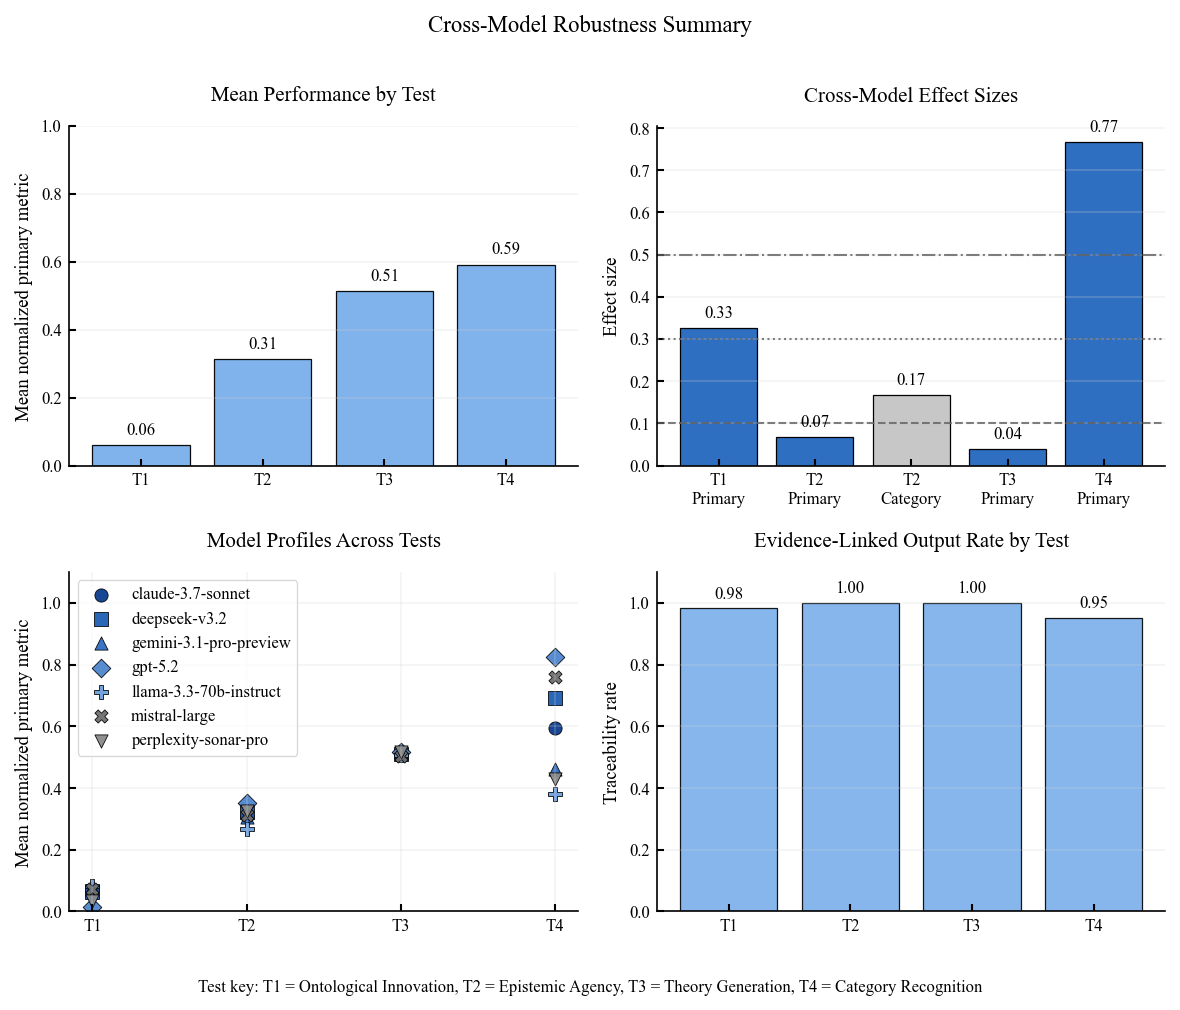

Saved: cross_test_summary.png


In [51]:
TEST_PLOT_LABELS = {
    'test1': 'T1\nOntological Innovation',
    'test2': 'T2\nEpistemic Agency',
    'test3': 'T3\nTheory Generation',
    'test4': 'T4\nCategory Recognition',
}

TEST_SHORT_LABELS = {
    'test1': 'T1',
    'test2': 'T2',
    'test3': 'T3',
    'test4': 'T4',
}

summary_rows = []
for test_name, prepared in prepared_results.items():
    summary_rows.append({
        'test': test_name,
        'title': TEST_PLOT_LABELS.get(test_name, TEST_SPECS[test_name]['short_title']),
        'short': TEST_SHORT_LABELS.get(test_name, test_name.upper()),
        'mean_primary_metric': prepared['primary_metric'].mean(),
        'traceability_rate': prepared['traceability'].mean() if 'traceability' in prepared.columns else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
generated_files = [name for name in generated_files if name not in {'cross_test_summary.png', 'model_performance_heatmap.png'}]

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# 1. Overall mean primary metric by test
ax = axes[0, 0]
if not summary_df.empty:
    plot_df = summary_df.sort_values('test')
    bars = ax.bar(
        plot_df['short'],
        plot_df['mean_primary_metric'],
        color=TRACEABILITY_SKY_COLOR,
        edgecolor='black',
        alpha=0.95,
    )
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Mean normalized primary metric')
    ax.set_title('Mean Performance by Test')
    ax.grid(axis='y', alpha=0.25)

    for bar, value in zip(bars, plot_df['mean_primary_metric']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f'{value:.2f}',
            ha='center',
            va='bottom',
            fontsize=8,
        )
else:
    ax.text(0.5, 0.5, 'No prepared test summaries available', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()

# 2. Effect sizes by analysis
ax = axes[0, 1]
if not effect_df.empty:
    effect_plot_df = effect_df.copy()

    # Compact x labels to avoid collisions in this multi-panel layout
    label_map = {
        ('T1: Ontological Innovation', 'Primary metric'): 'T1\nPrimary',
        ('T2: Epistemic Agency', 'Primary metric'): 'T2\nPrimary',
        ('T2: Epistemic Agency', 'Category distribution'): 'T2\nCategory',
        ('T3: Theory Generation', 'Primary metric'): 'T3\nPrimary',
        ('T4: Category Recognition', 'Primary metric'): 'T4\nPrimary',
    }
    effect_plot_df['label'] = [
        label_map.get((row['test_label'], row['analysis']), f"{row['test_label']}\n{row['analysis']}")
        for _, row in effect_plot_df.iterrows()
    ]

    colors = np.where(
        effect_plot_df['analysis'].eq('Primary metric'),
        SECONDARY_SKY_COLOR,
        CATEGORY_ACCENT_COLOR,
    )
    bars = ax.bar(effect_plot_df['label'], effect_plot_df['effect_size'], color=colors, edgecolor='black')
    ax.axhline(0.10, color=THRESHOLD_COLOR, linestyle='--', linewidth=1, alpha=0.8)
    ax.axhline(0.30, color=THRESHOLD_COLOR, linestyle=':', linewidth=1, alpha=0.8)
    ax.axhline(0.50, color=THRESHOLD_COLOR, linestyle='-.', linewidth=1, alpha=0.8)
    ax.set_ylabel('Effect size')
    ax.set_title('Cross-Model Effect Sizes')
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=0)

    for bar, value in zip(bars, effect_plot_df['effect_size']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f'{value:.2f}',
            ha='center',
            va='bottom',
            fontsize=8,
        )
else:
    ax.text(0.5, 0.5, 'No effect sizes available', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()

# 3. Model trajectories across tests (marker-only, no connecting lines)
ax = axes[1, 0]
if not model_metric_matrix.empty:
    trajectory_df = model_metric_matrix.sort_index()
    x_labels = [TEST_SHORT_LABELS.get(col, col.upper()) for col in trajectory_df.columns]
    x_positions = np.arange(len(x_labels))

    palette = sns.color_palette(MODEL_VISIBLE_COLORS, n_colors=len(trajectory_df.index))
    marker_cycle = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']

    for idx, (color, model) in enumerate(zip(palette, trajectory_df.index)):
        ax.scatter(
            x_positions,
            trajectory_df.loc[model].values,
            marker=marker_cycle[idx % len(marker_cycle)],
            s=40,
            alpha=0.95,
            label=model,
            color=color,
            edgecolors='black',
            linewidths=0.4,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Mean normalized primary metric')
    ax.set_title('Model Profiles Across Tests')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', frameon=True)
else:
    ax.text(0.5, 0.5, 'No model comparison matrix available', 
            ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()

# 4. Traceability rate by test
ax = axes[1, 1]
traceability_df = summary_df.dropna(subset=['traceability_rate']) if not summary_df.empty else pd.DataFrame()
if not traceability_df.empty:
    trace_plot_df = traceability_df.sort_values('test')
    bars = ax.bar(
        trace_plot_df['short'],
        trace_plot_df['traceability_rate'],
        color=TRACEABILITY_SKY_COLOR,
        edgecolor='black',
        alpha=0.9,
    )
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Traceability rate')
    ax.set_title('Evidence-Linked Output Rate by Test')
    ax.grid(axis='y', alpha=0.25)

    for bar, value in zip(bars, trace_plot_df['traceability_rate']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f'{value:.2f}',
            ha='center',
            va='bottom',
            fontsize=8,
        )
else:
    ax.text(0.5, 0.5, 'No traceability metrics available', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()

fig.suptitle('Cross-Model Robustness Summary', y=0.95)
fig.text(
    0.5,
    0.02,
    'Test key: T1 = Ontological Innovation, T2 = Epistemic Agency, T3 = Theory Generation, T4 = Category Recognition',
    ha='center',
    fontsize=8,
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plot_path = output_dir / 'cross_test_summary.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

if plot_path.name not in generated_files:
    generated_files.append(plot_path.name)

print(f'Saved: {plot_path.name}')

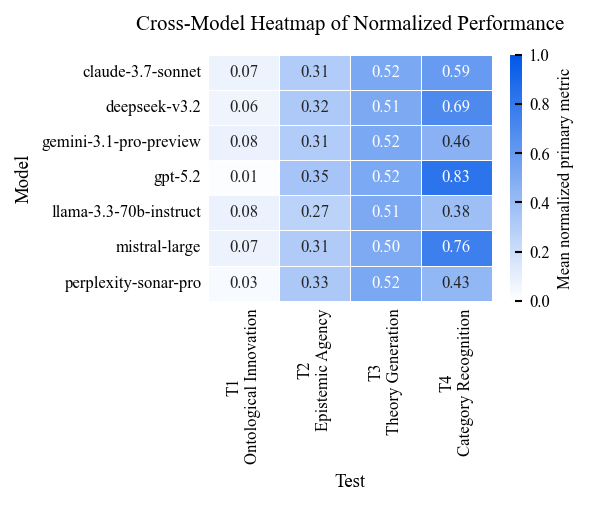

Saved: model_performance_heatmap.png


In [ ]:
if model_metric_matrix.empty:
    print('No model-by-test matrix was available for a heatmap.')
else:
    heatmap_df = model_metric_matrix.sort_index().copy()
    heatmap_df = heatmap_df.rename(columns=TEST_PLOT_LABELS)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    hm = sns.heatmap(
        heatmap_df,
        annot=True,
        annot_kws={'size': 8},
        fmt='.2f',
        cmap=WHITE_SKY_CMAP,
        vmin=0,
        vmax=1,
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'label': 'Mean normalized primary metric'},
        ax=ax
    )
    hm.collections[0].colorbar.set_label('Mean normalized primary metric', size=8)
    ax.set_title('Cross-Model Heatmap of Normalized Performance')
    ax.set_xlabel('Test')
    ax.set_ylabel('Model')
    ax.tick_params(bottom=False, left=False)
    plt.tight_layout()

    heatmap_path = output_dir / 'model_performance_heatmap.png'
    plt.savefig(heatmap_path, bbox_inches='tight')
    plt.show()

    if heatmap_path.name not in generated_files:
        generated_files.append(heatmap_path.name)

    print(f'Saved: {heatmap_path.name}')

## 5. Export Summary Report

In [23]:
# Create comprehensive summary
summary_report = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'tests_analyzed': list(prepared_results.keys()),
    'source_files': {test: str(path) for test, path in test_sources.items()},
    'models_analyzed': sorted(all_models),
    'metric_legend': metric_legend.to_dict(orient='records') if not metric_legend.empty else [],
    'cross_model_statistics': cross_model_stats,
    'meta_analysis': meta_results,
    'generated_files': generated_files,
    'key_findings': {
        'mean_cross_model_effect': meta_results.get('mean_effect_size'),
        'overall_average_interpretation': meta_results.get('overall_average_interpretation', 'Insufficient data'),
        'notable_exception': meta_results.get('notable_exception'),
        'highest_effect_result': meta_results.get('highest_effect_result'),
    },
}

def convert(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient='records')
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    return obj

summary_path = output_dir / 'cross_model_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_report, f, indent=2, default=convert)

print(f"\nSaved comprehensive summary to {summary_path}")

print("\n" + "=" * 80)
print("CROSS-MODEL ROBUSTNESS ANALYSIS COMPLETE")
print("=" * 80)
print(f"\nTests analyzed: {len(prepared_results)}")
print(f"Models compared: {len(all_models)}")
if meta_results.get('mean_effect_size') is not None:
    print(f"Average cross-model effect size: {meta_results['mean_effect_size']:.3f}")
print(f"Overall interpretation: {meta_results.get('overall_average_interpretation', 'Insufficient data')}")
if meta_results.get('notable_exception') is not None:
    print(f"Notable exception: {meta_results['notable_exception']}")

print("\nGenerated outputs:")
for file_name in generated_files + [summary_path.name]:
    print(f"  - {file_name}")


Saved comprehensive summary to results/cross_model/cross_model_summary.json

CROSS-MODEL ROBUSTNESS ANALYSIS COMPLETE

Tests analyzed: 4
Models compared: 7
Average cross-model effect size: 0.273
Overall interpretation: Average cross-model variation is small, so the overall pattern is broadly robust across models.
Notable exception: The average pattern suggests robustness, but T4: Category Recognition shows a large model effect for primary metric (effect size = 0.766).

Generated outputs:
  - cross_test_summary.png
  - model_performance_heatmap.png
  - cross_model_summary.json


## Summary

This notebook now frames Section 5.7 as a publication-ready cross-model robustness analysis focused on analyzable canonical outputs.

1. It loads each test from the processed result file that best matches the section-level analysis workflow, with Test 2 drawing from the richer detailed export.
2. It maps each test onto a native primary metric, so comparisons are made on the correct processed outcome for that test rather than on a forced shared label.
3. It separates the **average cross-model pattern** from **test-specific exceptions**, which is important because the aggregate effect-size profile is modest overall while Test 4 still shows strong model dependence.
4. It exports dissertation-ready figures and a structured JSON summary that preserves both the average interpretation and the strongest exception.

**Interpretation emphasis for Section 5.7**

1. The average effect size across available analyses should be read as the broad cross-model signal.
2. The strongest single-test deviation should be reported separately, especially when one test remains much more model-sensitive than the others.
3. For the current outputs, the overall conclusion is one of broad robustness with a clear exception in category recognition.

**Figure-reading guidance**

1. The top-left panel summarizes each test’s mean normalized performance on its own processed metric.
2. The top-right panel shows where model effects are statistically strongest and whether they concern primary metrics or categorical outcome distributions.
3. The bottom-left panel shows model profiles across tests rather than implying a single universal ranking.
4. The bottom-right panel keeps the traceability perspective visible so novelty-like results are not read without their evidence-linkage context.